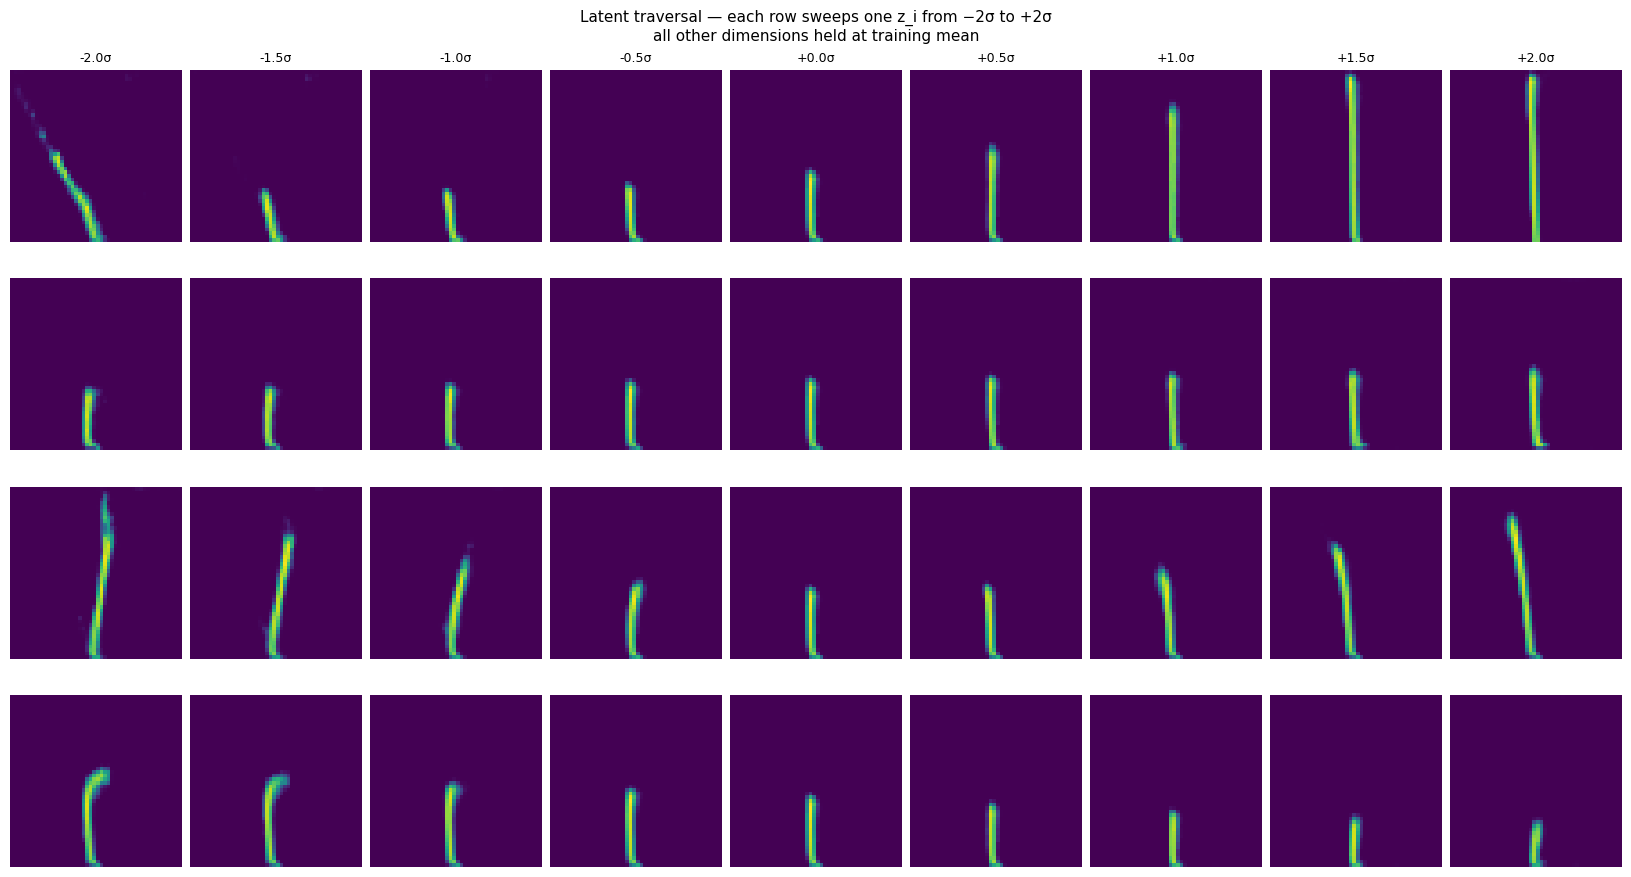

In [7]:
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.models.configVAE import VAE

# ── load config + build name ──────────────────────────────────────────────────
with open("../../configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

name = (
    f"model_{cfg['model']['type']}"
    f"_latent{cfg['model']['latent']}"
    f"_ch{'_'.join(str(c) for c in cfg['model']['channels'])}"
    f"_beta{cfg['train']['beta']}"
    f"_lr{cfg['optimizer']['lr']}"
    f"_epoch{cfg['train']['epochs']}"
    f"_act{cfg['model']['activation']}"
    f"_kern{cfg['model']['kernel']}"
    f"_stride{cfg['model']['stride']}"
    f"_pad{cfg['model']['padding']}"
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = VAE(
    input_hw=tuple(cfg["model"]["input_hw"]),
    latent=cfg["model"]["latent"],
    channels=cfg["model"]["channels"],
    kernel=cfg["model"]["kernel"],
    stride=cfg["model"]["stride"],
    padding=cfg["model"]["padding"],
    activation=cfg["model"]["activation"],
    p_enc=cfg["model"]["dropout"],
).to(device)
model.load_state_dict(torch.load(
    Path(cfg["output"]["dir"]) / (name + ".pt"), map_location=device
))
model.eval()

# ── load training latents ─────────────────────────────────────────────────────
train = np.load(Path(cfg["output"]["inference_dir"]) / name / "train.npz")
train_latents = train["latents"]   # (N, 4)

# mu  = train_latents.mean(axis=0)
mu  = train_latents[10]                 # randomly chosen proton event
sig = train_latents.std(axis=0)

# ── traversal ─────────────────────────────────────────────────────────────────
N_STEPS = 9
N_DIMS  = cfg["model"]["latent"]
CHANNEL = 0                        # 0 = collection, 1 = induction

steps = np.linspace(-2, 2, N_STEPS)

fig, axes = plt.subplots(
    N_DIMS, N_STEPS,
    figsize=(N_STEPS * 1.8, N_DIMS * 2.2),
    constrained_layout=True,
)

with torch.no_grad():
    for i in range(N_DIMS):
        z_batch = np.tile(mu, (N_STEPS, 1))
        z_batch[:, i] = mu[i] + steps * sig[i]

        z_tensor = torch.tensor(z_batch, dtype=torch.float32).to(device)
        recon = model.decode(z_tensor).cpu().numpy()   # (9, 2, H, W)
        images = recon[:, CHANNEL, :, :]               # (9, H, W)

        vmax = images.max()

        for j in range(N_STEPS):
            ax = axes[i, j]
            ax.imshow(images[j], origin="lower", cmap="viridis", vmin=0, vmax=vmax)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(f"z{i}", fontsize=11, rotation=0, labelpad=28, va="center")
            if i == 0:
                ax.set_title(f"{steps[j]:+.1f}σ", fontsize=9)

fig.suptitle(
    "Latent traversal — each row sweeps one z_i from −2σ to +2σ\n"
    "all other dimensions held at training mean",
    fontsize=11,
)
plt.savefig("../../figs/latents-features/latent_traversal.png", dpi=150, bbox_inches="tight")
plt.show()